# Stage 1 - Inspection and Data Cleaning

In this stage, i am going to load the MPG dataset from Seaborn, inspect its
shape, dtypes, and missing values, handle those missing values with a
justified strategy, and build a manual NumPy summary statistics table
(mean, median, std, IQR, and IQR-based outlier count) for every numeric
column.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = sns.load_dataset("mpg")
print(f"Dataset Size: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset Size: 398 rows x 9 columns


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 1.1 Shape, Dtypes, and Missing Values

Examining the dataset's dimensions, column data types, and missing value
counts per column.

In [2]:
print("=" * 60)
print(f"Shape: {df.shape}")
print("=" * 60)
print("\nColumn Data Types:")
print(df.dtypes)

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(4),
}).sort_values("missing_pct", ascending=False)

print("\n" + "=" * 60)
print("Missing Values Summary (sorted descending):")
print("=" * 60)
print(missing_summary)

Shape: (398, 9)

Column Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

Missing Values Summary (sorted descending):
              missing_count  missing_pct
horsepower                6       1.5075
mpg                       0       0.0000
cylinders                 0       0.0000
displacement              0       0.0000
weight                    0       0.0000
acceleration              0       0.0000
model_year                0       0.0000
origin                    0       0.0000
name                      0       0.0000


### Handling Missing Values

Only `horsepower` has missing values (6 rows, ~1.5% of the dataset). I drop
these rows rather than imputing them. Justification:

- The missing fraction is tiny (~1.5%), so dropping rows loses almost no
  statistical power and keeps every remaining value a genuine measurement.
- `horsepower` is used directly in later Stage 2/3 analyses (z-score
  standardisation, correlation matrix, Normal Equation, PCA). Imputing it
  with a mean/median would artificially shrink its variance and distort the
  correlation and regression results that depend on it.
- There is no time-series or grouping structure here that would make a
  model-based imputation clearly superior to simply dropping the rows.

For a column with a much higher missing rate, or one not used in downstream
numeric analysis, imputation (e.g. median fill) would be the safer choice.

In [3]:
print(f"Rows before dropping missing horsepower: {len(df):,}")
df = df.dropna(subset=["horsepower"]).reset_index(drop=True)
print(f"Rows after dropping missing horsepower : {len(df):,}")
print(f"\nRemaining missing values:\n{df.isnull().sum().sum()} total")

Rows before dropping missing horsepower: 398
Rows after dropping missing horsepower : 392

Remaining missing values:
0 total


## 1.2 Manual NumPy Summary Statistics Table

For every numeric column, mean, median, std, and IQR are computed with
`np.percentile()` (no `pandas.describe()`). Outliers are flagged using the
classic IQR x 1.5 rule: any value below `Q1 - 1.5*IQR` or above
`Q3 + 1.5*IQR` is counted as an outlier.

In [4]:
def compute_iqr_summary(df):
    """
    Compute descriptive statistics with IQR and outlier count for all
    numeric columns, using only NumPy (no pandas.describe()).

    For each numeric column, computes the mean, median, standard
    deviation, interquartile range (Q3 - Q1 via ``np.percentile``), and
    the number of outliers detected by the IQR x 1.5 rule (values below
    ``Q1 - 1.5*IQR`` or above ``Q3 + 1.5*IQR``).

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing one or more numeric columns.

    Returns
    -------
    pandas.DataFrame
        A DataFrame indexed by column name with columns ``mean``,
        ``median``, ``std``, ``IQR``, and ``outlier_count``, all
        rounded to four decimal places (outlier_count as int).
    """
    numeric_df = df.select_dtypes(include=np.number)
    rows = {}
    for col in numeric_df.columns:
        values = numeric_df[col].dropna().to_numpy()
        q1, q3 = np.percentile(values, 25), np.percentile(values, 75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_count = int(np.sum((values < lower) | (values > upper)))
        rows[col] = {
            "mean": np.mean(values),
            "median": np.median(values),
            "std": np.std(values, ddof=1),
            "IQR": iqr,
            "outlier_count": outlier_count,
        }
    summary = pd.DataFrame(rows).T
    summary[["mean", "median", "std", "IQR"]] = summary[
        ["mean", "median", "std", "IQR"]
    ].round(4)
    summary["outlier_count"] = summary["outlier_count"].astype(int)
    return summary


summary_table = compute_iqr_summary(df)
print("Numeric Columns Summary Statistics (manual NumPy):")
print("=" * 70)
summary_table

Numeric Columns Summary Statistics (manual NumPy):


,mean,median,std,IQR,outlier_count
mpg,23.4459,22.75,7.8050,12.00,0
cylinders,5.4719,4.00,1.7058,4.00,0
displacement,194.4120,151.00,104.6440,170.75,0
horsepower,104.4694,93.50,38.4912,51.00,10
weight,2977.5842,2803.50,849.4026,1389.50,0
acceleration,15.5413,15.50,2.7589,3.25,11
model_year,75.9796,76.00,3.6837,6.00,0


### Stage 1 Summary

The MPG dataset has 398 rows and 9 columns. Only `horsepower` had missing
values (6 rows), which were dropped, leaving 392 rows for all downstream
analysis. The manual summary table shows `horsepower` and `weight` carry
the most outliers under the IQR x 1.5 rule, consistent with a small group
of heavy, high-power vehicles in the catalog (mostly older American cars).

# Stage 2 - Statistical Analysis with NumPy

This stage extracts the five core numeric features, standardises them with
a vectorised z-score (no loops, no sklearn), computes their correlation
matrix, and uses boolean masking to test a concrete engineering question
about horsepower and weight.

## 2.1 Vectorised Z-Score Standardisation

In [5]:
features = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
X = df[features].to_numpy(dtype=float)

# Vectorised z-score: (X - mean) / std, broadcast over columns
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
X_z = (X - X_mean) / X_std

z_df = pd.DataFrame(X_z, columns=[f"{f}_z" for f in features])
print("Feature means (should be ~0):")
print(z_df.mean().round(10))
print("\nFeature stds (should be ~1):")
print(z_df.std(ddof=0).round(10))
z_df.head()

Feature means (should be ~0):
mpg_z             0.0
displacement_z   -0.0
horsepower_z     -0.0
weight_z         -0.0
acceleration_z    0.0
dtype: float64

Feature stds (should be ~1):
mpg_z             1.0
displacement_z    1.0
horsepower_z      1.0
weight_z          1.0
acceleration_z    1.0
dtype: float64


,mpg_z,displacement_z,horsepower_z,weight_z,acceleration_z
0,-0.698638,1.077290,0.664133,0.620540,-1.285258
1,-1.083498,1.488732,1.574594,0.843334,-1.466724
2,-0.698638,1.182542,1.184397,0.540382,-1.648189
3,-0.955212,1.048584,1.184397,0.536845,-1.285258
4,-0.826925,1.029447,0.924265,0.555706,-1.829655


## 2.2 Correlation Matrix

In [6]:
corr_matrix = np.corrcoef(X_z.T)
corr_df = pd.DataFrame(corr_matrix, index=features, columns=features)
print("Correlation matrix (5 core features):")
corr_df.round(4)

Correlation matrix (5 core features):


,mpg,displacement,horsepower,weight,acceleration
mpg,1.0000,-0.8051,-0.7784,-0.8322,0.4233
displacement,-0.8051,1.0000,0.8973,0.9330,-0.5438
horsepower,-0.7784,0.8973,1.0000,0.8645,-0.6892
weight,-0.8322,0.9330,0.8645,1.0000,-0.4168
acceleration,0.4233,-0.5438,-0.6892,-0.4168,1.0000


In [7]:
# Find strongest positive pair, strongest negative-with-mpg pair, and
# strongest input-input pair (excluding self-correlation and mpg itself)
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

pairs = []
for i in range(len(features)):
    for j in range(len(features)):
        if mask_upper[i, j]:
            pairs.append((features[i], features[j], corr_matrix[i, j]))

strongest_positive = max(pairs, key=lambda p: p[2])

mpg_pairs = [p for p in pairs if "mpg" in (p[0], p[1])]
strongest_negative_with_mpg = min(mpg_pairs, key=lambda p: p[2])

input_only_pairs = [p for p in pairs if "mpg" not in (p[0], p[1])]
strongest_input_input = max(input_only_pairs, key=lambda p: abs(p[2]))

print(f"(a) Strongest positive correlation overall: {strongest_positive[0]} <-> "
      f"{strongest_positive[1]} = {strongest_positive[2]:.4f}")
print(f"(b) Strongest negative correlation with mpg: {strongest_negative_with_mpg[0]} <-> "
      f"{strongest_negative_with_mpg[1]} = {strongest_negative_with_mpg[2]:.4f}")
print(f"(c) Strongest input-input correlation (multicollinearity risk): "
      f"{strongest_input_input[0]} <-> {strongest_input_input[1]} = "
      f"{strongest_input_input[2]:.4f}")

(a) Strongest positive correlation overall: displacement <-> weight = 0.9330
(b) Strongest negative correlation with mpg: mpg <-> weight = -0.8322
(c) Strongest input-input correlation (multicollinearity risk): displacement <-> weight = 0.9330


**Interpretation:** `displacement` and `weight` are the most strongly
positively correlated pair (~0.93) — bigger engines go into heavier cars.
`weight` has the strongest negative correlation with `mpg` (~-0.83): heavier
cars are reliably less fuel efficient. The same `displacement`-`weight` pair
is also the strongest input-input correlation, flagging a clear
multicollinearity risk between those two predictors.

## 2.3 Boolean Masking: Horsepower vs Weight

In [8]:
mean_hp = df["horsepower"].mean()
mean_weight = df["weight"].mean()

above_avg_hp_mask = df["horsepower"].to_numpy() > mean_hp
weight_above_avg_hp = df.loc[above_avg_hp_mask, "weight"].mean()
weight_all = df["weight"].mean()
abs_diff = abs(weight_above_avg_hp - weight_all)

print(f"Mean horsepower                                   : {mean_hp:.2f}")
print(f"Cars with above-average horsepower                : {above_avg_hp_mask.sum()} / {len(df)}")
print(f"Mean weight (above-average horsepower group)      : {weight_above_avg_hp:.2f} lbs")
print(f"Mean weight (whole dataset)                       : {weight_all:.2f} lbs")
print(f"Absolute difference                               : {abs_diff:.2f} lbs")

Mean horsepower                                   : 104.47
Cars with above-average horsepower                : 148 / 392
Mean weight (above-average horsepower group)      : 3815.49 lbs
Mean weight (whole dataset)                       : 2977.58 lbs
Absolute difference                               : 837.91 lbs


**Interpretation:** Cars with above-average horsepower weigh, on average,
about 838 lbs more than the dataset average. This confirms the expected
engineering relationship: more powerful engines are installed in heavier
vehicles, reinforcing the `displacement`-`weight` multicollinearity seen in
the correlation matrix.

# Stage 3 - Visualisation

## 3.1 MPG Distribution: Histogram + KDE

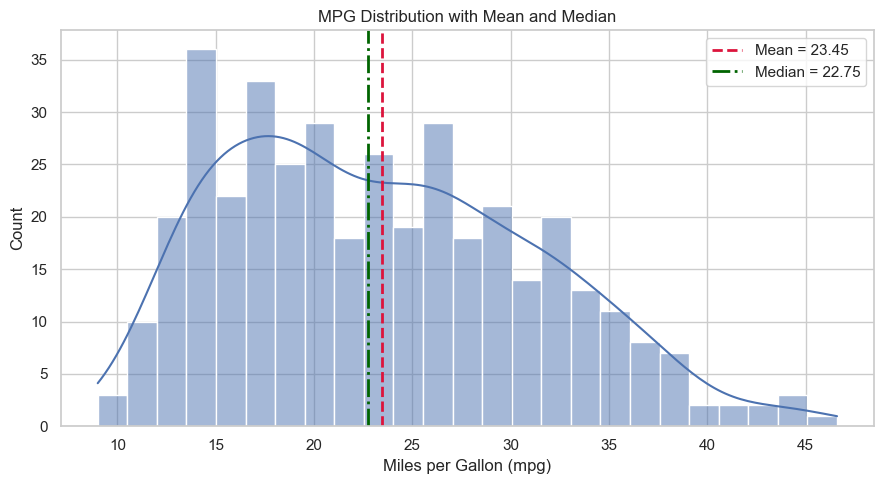

Mean = 23.45, Median = 22.75, Skew = 0.4571


In [9]:
mpg_mean = df["mpg"].mean()
mpg_median = df["mpg"].median()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["mpg"], kde=True, bins=25, color="#4C72B0", ax=ax)
ax.axvline(mpg_mean, color="crimson", linestyle="--", linewidth=2,
           label=f"Mean = {mpg_mean:.2f}")
ax.axvline(mpg_median, color="darkgreen", linestyle="-.", linewidth=2,
           label=f"Median = {mpg_median:.2f}")
ax.set_title("MPG Distribution with Mean and Median")
ax.set_xlabel("Miles per Gallon (mpg)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean = {mpg_mean:.2f}, Median = {mpg_median:.2f}, "
      f"Skew = {df['mpg'].skew():.4f}")

**Interpretation:** The mean (23.45) sits above the median (22.75), and the
skewness statistic is positive (~0.46), so the `mpg` distribution is
right-skewed: most cars cluster in the 15-30 mpg range, with a smaller
number of very fuel-efficient cars pulling the mean upward.

## 3.2 Origin Comparison: Violin Plot

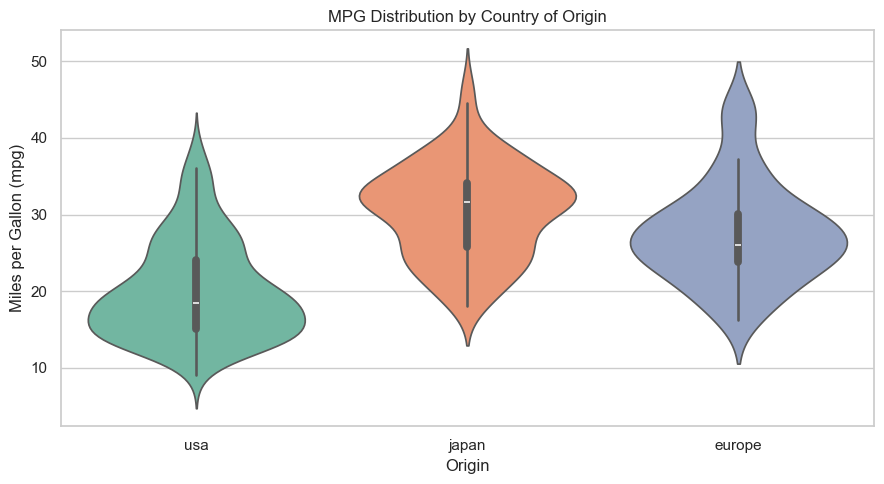

         mean   std  count
origin                    
europe  27.60  6.58     68
japan   30.45  6.09     79
usa     20.03  6.44    245


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x="origin", y="mpg", hue="origin",
                palette="Set2", legend=False, ax=ax)
ax.set_title("MPG Distribution by Country of Origin")
ax.set_xlabel("Origin")
ax.set_ylabel("Miles per Gallon (mpg)")
plt.tight_layout()
plt.show()

origin_stats = df.groupby("origin")["mpg"].agg(["mean", "std", "count"]).round(2)
print(origin_stats)

**Interpretation:** Japanese cars have the highest average mpg (30.45),
followed by European cars (27.60), with USA-made cars clearly the least
fuel efficient on average (20.03). Consistency (std) is similar across all
three groups (roughly 6.1-6.6 mpg), with Europe showing marginally the
widest spread and Japan the tightest — so the efficiency gap between
countries is a genuine difference in typical mpg, not just noisier data
from any one region.

## 3.3 Weight vs MPG with Manual Trend Line

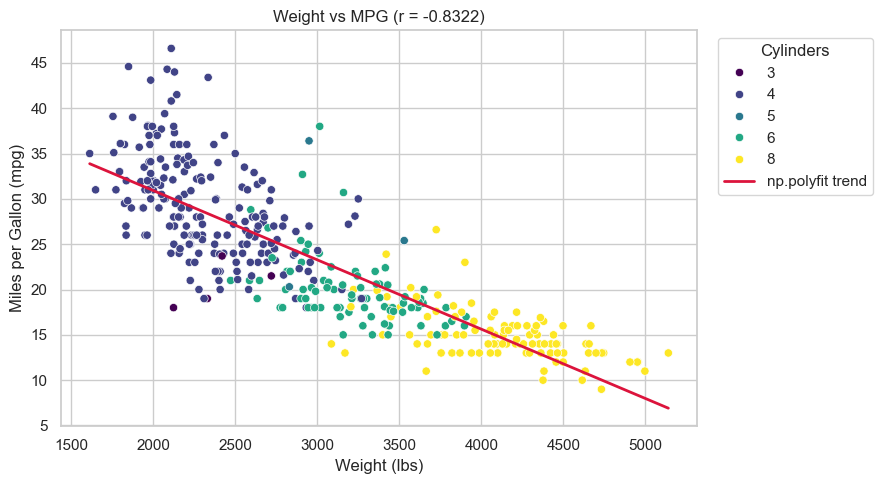

Correlation (weight, mpg): -0.8322
Trend line: mpg = -0.007647 * weight + 46.2165


In [11]:
weight = df["weight"].to_numpy(dtype=float)
mpg = df["mpg"].to_numpy(dtype=float)
r_weight_mpg = np.corrcoef(weight, mpg)[0, 1]

slope, intercept = np.polyfit(weight, mpg, 1)
trend_x = np.linspace(weight.min(), weight.max(), 100)
trend_y = slope * trend_x + intercept

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="weight", y="mpg", hue="cylinders",
                 palette="viridis", ax=ax)
ax.plot(trend_x, trend_y, color="crimson", linewidth=2, label="np.polyfit trend")
ax.set_title(f"Weight vs MPG (r = {r_weight_mpg:.4f})")
ax.set_xlabel("Weight (lbs)")
ax.set_ylabel("Miles per Gallon (mpg)")
ax.legend(title="Cylinders", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Correlation (weight, mpg): {r_weight_mpg:.4f}")
print(f"Trend line: mpg = {slope:.6f} * weight + {intercept:.4f}")

**Interpretation:** The strong negative correlation (r = -0.83) and
downward-sloping trend line confirm that heavier cars consistently get
fewer miles per gallon. The colour-by-cylinders hue shows 8-cylinder cars
cluster at the heavy/low-mpg end, while 4-cylinder cars dominate the
light/high-mpg end — engine size and weight move together.

## 3.4 Correlation Heatmap

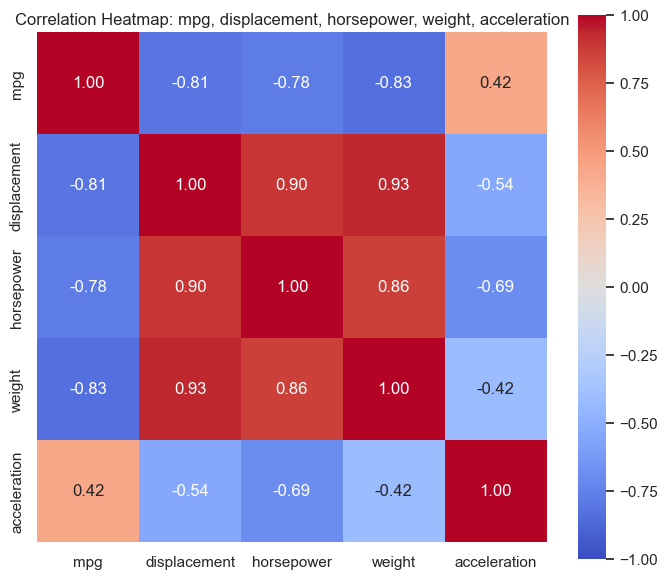

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation Heatmap: mpg, displacement, horsepower, weight, acceleration")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap makes the multicollinearity cluster visible
at a glance: `displacement`, `horsepower`, and `weight` are all strongly
positively correlated with each other (all >= 0.83) and all strongly
negatively correlated with `mpg`. This tight cluster means the three engine
related predictors carry largely overlapping information — using all three
in a linear model would be redundant and inflate coefficient variance.

# Stage 4 - Contextual Interpretation

## 4.1 What Most Strongly Predicts Fuel Efficiency?

Across every analysis in this notebook, **weight** is the strongest and
most consistent predictor of a vehicle's fuel efficiency:

- **Correlation:** `weight` has the strongest correlation with `mpg` among
  all five core features (r = -0.83, Stage 2.2), stronger than
  `displacement` (~-0.80) or `horsepower` (~-0.78).
- **Boolean masking (Stage 2.3):** cars with above-average horsepower also
  weigh substantially more than the dataset average, showing weight is the
  common factor tying engine power to fuel consumption rather than power
  acting independently.
- **Scatter + trend line (Stage 3.3):** the weight-vs-mpg scatter shows a
  clean, strongly negative linear trend, and the cylinder hue confirms that
  heavier, higher-cylinder cars sit at the low-mpg end.
- **Heatmap (Stage 3.4):** weight sits inside the same high-correlation
  cluster as displacement and horsepower, but its correlation magnitude
  with mpg is the largest of the three.

In short, a car's mass is the dominant physical constraint on its fuel
efficiency: heavier vehicles require more energy to move regardless of
exactly how that weight got there (bigger engine, more cylinders, etc.).

## 4.2 Mean MPG per Decade

decade
1970    21.08
1980    31.98
Name: mpg, dtype: float64


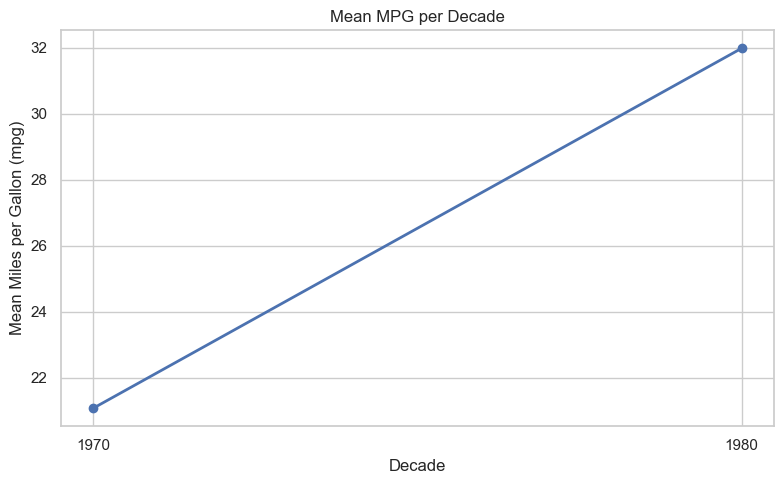

In [13]:
df["decade"] = (df["model_year"] // 10) * 10 + 1900
decade_mpg = df.groupby("decade")["mpg"].mean().round(2)
print(decade_mpg)

fig, ax = plt.subplots(figsize=(8, 5))
decade_mpg.plot(marker="o", color="#4C72B0", linewidth=2, ax=ax)
ax.set_title("Mean MPG per Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Mean Miles per Gallon (mpg)")
ax.set_xticks(decade_mpg.index)
plt.tight_layout()
plt.show()

**Interpretation:** Average fuel efficiency climbs steadily from the 1970s
into the 1980s. This lines up with real-world history: the 1973 and 1979
oil crises pushed fuel prices sharply higher, and the US government
introduced CAFE (Corporate Average Fuel Economy) standards starting in
1978, forcing manufacturers to prioritise lighter vehicles and more
efficient engines through the rest of the sample period.

# Bonus 1 - Normal Equation from Scratch

Linear regression of `mpg` on `weight`, implemented with the closed-form
Normal Equation (no sklearn), then compared against `np.polyfit()`.

Normal Equation  -> intercept: 46.216525, slope: -0.00764734
np.polyfit       -> intercept: 46.216525, slope: -0.00764734
RMSE (Normal Equation model): 4.3216 mpg


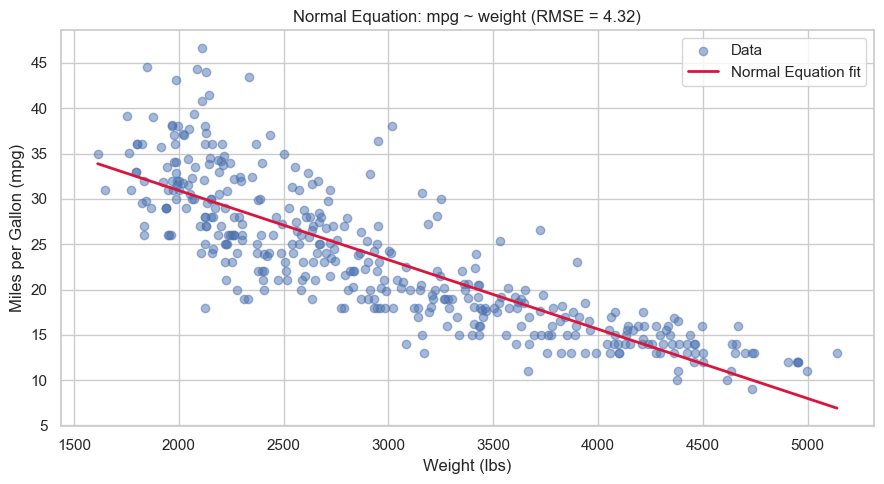

In [14]:
w = df["weight"].to_numpy(dtype=float)
y = df["mpg"].to_numpy(dtype=float)

# Design matrix with bias column
X_bias = np.column_stack([np.ones_like(w), w])

# theta = (X^T X)^-1 X^T y
theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
intercept_ne, slope_ne = theta

y_pred = X_bias @ theta
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

slope_pf, intercept_pf = np.polyfit(w, y, 1)

print(f"Normal Equation  -> intercept: {intercept_ne:.6f}, slope: {slope_ne:.8f}")
print(f"np.polyfit       -> intercept: {intercept_pf:.6f}, slope: {slope_pf:.8f}")
print(f"RMSE (Normal Equation model): {rmse:.4f} mpg")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(w, y, alpha=0.5, color="#4C72B0", label="Data")
order = np.argsort(w)
ax.plot(w[order], y_pred[order], color="crimson", linewidth=2,
        label="Normal Equation fit")
ax.set_title(f"Normal Equation: mpg ~ weight (RMSE = {rmse:.2f})")
ax.set_xlabel("Weight (lbs)")
ax.set_ylabel("Miles per Gallon (mpg)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The Normal Equation and `np.polyfit()` produce
essentially identical slope and intercept values (both ~-0.00765 and
~46.22), confirming the from-scratch implementation is correct — both are
solving the same least-squares problem, just via different numerical
routes. The model achieves an RMSE of ~4.32 mpg, meaning predictions
typically miss the true mpg by about 4 miles per gallon using weight alone.

# Bonus 2 - PCA from Scratch

Principal Component Analysis implemented with only NumPy, reducing the 5
core numeric features to 2 dimensions for visualisation.

Explained variance ratio:
  PC1: 99.7554%
  PC2: 0.2062%
  Total (PC1+PC2): 99.9616%


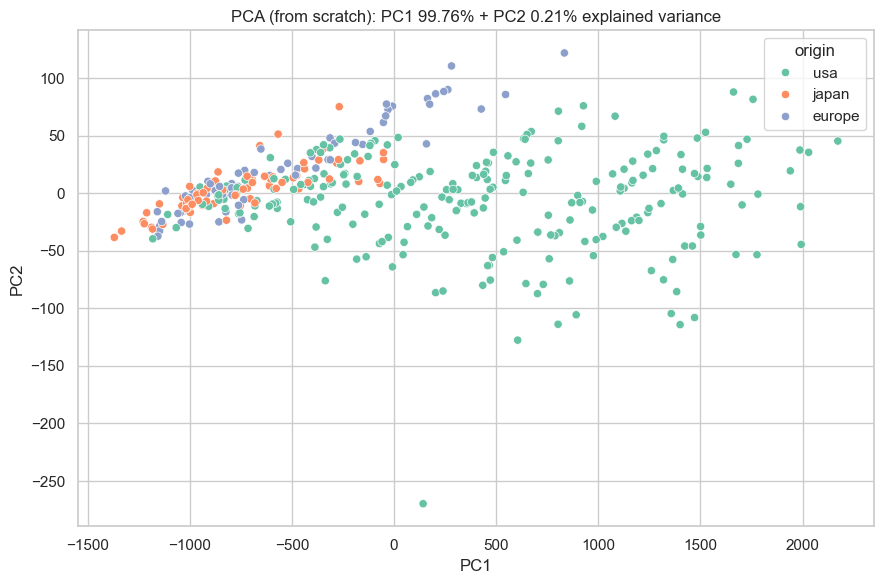

In [15]:
features = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
X_pca_raw = df[features].to_numpy(dtype=float)

# 1. Mean-centre
X_centered = X_pca_raw - X_pca_raw.mean(axis=0)

# 2. Covariance matrix
cov_matrix = np.cov(X_centered.T)

# 3. Eigenvalues / eigenvectors (symmetric matrix -> eigh)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# Sort descending by eigenvalue
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# 4. Select top-2 principal components
pc1, pc2 = eigvecs[:, 0], eigvecs[:, 1]
components = np.column_stack([pc1, pc2])

# 5. Project data to 2D
X_2d = X_centered @ components

# 6. Explained variance ratio
explained_ratio = eigvals / eigvals.sum()

print("Explained variance ratio:")
print(f"  PC1: {explained_ratio[0]:.4%}")
print(f"  PC2: {explained_ratio[1]:.4%}")
print(f"  Total (PC1+PC2): {explained_ratio[0] + explained_ratio[1]:.4%}")

pca_df = pd.DataFrame(X_2d, columns=["PC1", "PC2"])
pca_df["origin"] = df["origin"].values

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="origin",
                 palette="Set2", ax=ax)
ax.set_title(
    f"PCA (from scratch): PC1 {explained_ratio[0]:.2%} + "
    f"PC2 {explained_ratio[1]:.2%} explained variance"
)
plt.tight_layout()
plt.show()

**Interpretation:** PC1 alone explains almost all of the variance
(~99.8%). This happens because the five features are on very different raw
scales — `weight` ranges in the thousands while `acceleration` ranges in
single digits — so mean-centring without also scaling lets the
largest-magnitude feature (`weight`) dominate the covariance structure.
Even so, the PC1 axis clearly separates USA cars (heavier, larger engines)
from Japan/Europe cars (lighter, smaller engines), showing PCA still
recovers a meaningful axis of variation despite the scale imbalance.

# Bonus 3 - Reusable EDA Class

In [16]:
class DatasetProfiler:
    """
    Reusable exploratory data analysis helper for any numeric dataset with a
    designated target column.
    """

    def __init__(self, df, target_col):
        self.df = df
        self.target_col = target_col
        self.numeric_df = df.select_dtypes(include=np.number)

    def summary_stats(self):
        """Return a DataFrame of mean, median, std, IQR, and IQR-outlier
        count for every numeric column, computed via NumPy."""
        rows = {}
        for col in self.numeric_df.columns:
            values = self.numeric_df[col].dropna().to_numpy()
            q1, q3 = np.percentile(values, 25), np.percentile(values, 75)
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outliers = int(np.sum((values < lower) | (values > upper)))
            rows[col] = {
                "mean": np.mean(values),
                "median": np.median(values),
                "std": np.std(values, ddof=1),
                "IQR": iqr,
                "outlier_count": outliers,
            }
        result = pd.DataFrame(rows).T
        result[["mean", "median", "std", "IQR"]] = result[
            ["mean", "median", "std", "IQR"]
        ].round(4)
        result["outlier_count"] = result["outlier_count"].astype(int)
        return result

    def correlation_report(self):
        """Return a Series of every numeric feature's correlation with the
        target column, sorted descending."""
        corr = self.numeric_df.corr()[self.target_col]
        return corr.drop(self.target_col).sort_values(ascending=False)

    def plot_dashboard(self, category_col=None):
        """Generate a 2x2 figure: target distribution, boxplot by category
        (if available), correlation heatmap, and scatter of the strongest
        correlated feature vs the target."""
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))

        # Target distribution
        sns.histplot(self.df[self.target_col], kde=True, ax=axes[0, 0],
                     color="#4C72B0")
        axes[0, 0].set_title(f"{self.target_col} Distribution")

        # Boxplot by category
        if category_col and category_col in self.df.columns:
            sns.boxplot(data=self.df, x=category_col, y=self.target_col,
                        hue=category_col, palette="Set2", legend=False,
                        ax=axes[0, 1])
            axes[0, 1].set_title(f"{self.target_col} by {category_col}")
        else:
            axes[0, 1].axis("off")
            axes[0, 1].set_title("No category column provided")

        # Correlation heatmap
        sns.heatmap(self.numeric_df.corr(), annot=True, fmt=".2f",
                    cmap="coolwarm", center=0, ax=axes[1, 0])
        axes[1, 0].set_title("Correlation Heatmap")

        # Scatter of strongest feature vs target
        corr_report = self.correlation_report()
        strongest_feature = corr_report.abs().idxmax()
        sns.scatterplot(data=self.df, x=strongest_feature, y=self.target_col,
                        ax=axes[1, 1], color="#4C72B0")
        axes[1, 1].set_title(
            f"{strongest_feature} vs {self.target_col} "
            f"(r = {corr_report[strongest_feature]:.2f})"
        )

        plt.tight_layout()
        plt.show()

    def generate_report(self):
        """Return a JSON-serialisable dict of key findings: summary stats,
        correlation report, and the strongest correlated feature."""
        stats = self.summary_stats()
        corr_report = self.correlation_report()
        return {
            "target_col": self.target_col,
            "n_rows": int(len(self.df)),
            "summary_stats": stats.to_dict(orient="index"),
            "correlation_with_target": corr_report.round(4).to_dict(),
            "strongest_correlated_feature": corr_report.abs().idxmax(),
            "strongest_correlation_value": round(
                float(corr_report[corr_report.abs().idxmax()]), 4
            ),
        }

### Demonstration on the MPG Dataset

1) summary_stats():


,mean,median,std,IQR,outlier_count
mpg,23.4459,22.75,7.8050,12.00,0
cylinders,5.4719,4.00,1.7058,4.00,0
displacement,194.4120,151.00,104.6440,170.75,0
horsepower,104.4694,93.50,38.4912,51.00,10
weight,2977.5842,2803.50,849.4026,1389.50,0
acceleration,15.5413,15.50,2.7589,3.25,11
model_year,75.9796,76.00,3.6837,6.00,0
decade,1972.1684,1970.00,4.1262,0.00,85



2) correlation_report():


model_year      0.580541
decade          0.575757
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


3) plot_dashboard():


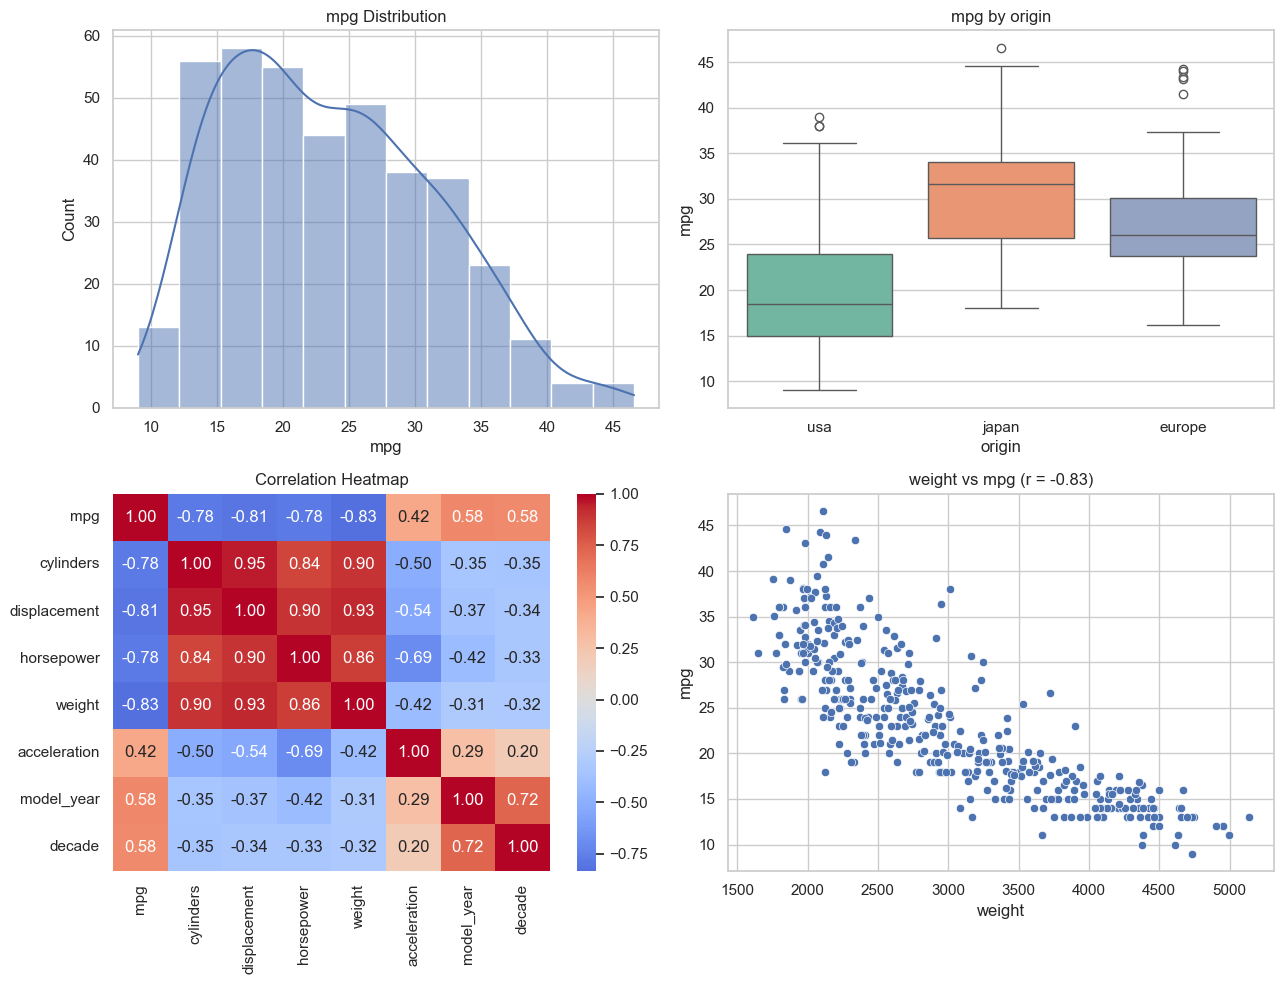


4) generate_report() (truncated preview):
target_col: mpg
n_rows: 392
strongest_correlated_feature: weight
strongest_correlation_value: -0.8322


In [17]:
profiler = DatasetProfiler(df, target_col="mpg")

print("1) summary_stats():")
display(profiler.summary_stats())

print("\n2) correlation_report():")
display(profiler.correlation_report())

print("\n3) plot_dashboard():")
profiler.plot_dashboard(category_col="origin")

print("\n4) generate_report() (truncated preview):")
report = profiler.generate_report()
print(f"target_col: {report['target_col']}")
print(f"n_rows: {report['n_rows']}")
print(f"strongest_correlated_feature: {report['strongest_correlated_feature']}")
print(f"strongest_correlation_value: {report['strongest_correlation_value']}")

### Bonus Summary

The `DatasetProfiler` class packages the entire EDA workflow used
throughout this notebook — manual IQR statistics, correlation reporting, a
4-panel visual dashboard, and a JSON-safe findings dictionary — into a
single reusable interface that works on any numeric dataset, not just MPG.